In [27]:
import mcmr

In [34]:
geom = mcmr.Geometry(
    x_world=50, y_world=50,
    default_material="Pb",
    default_source=0,
    bc_top="reflective",
    bc_bot="vacuum",
    bc_left="reflective",
    bc_right="vacuum",
)

geom.add_region(3, 3, 47, 47, material="Fe")
for i in range(7, 47, 8):
    geom.fill_col(i, i+4, material="C", source=1)
for i in range(7, 47, 8):
    geom.fill_row(i, i+4, material="Fe", source=0)

In [35]:
world = geom.build()

In [36]:
sim = world.run(N=10000)

              MCMR Simulation Engine               
 Total Particle   : 10000
running...
Progress: [10000/10000] (100%)
 Simulation End in 7.7524 seconds.



In [37]:
t = sim.get_tally()
print(t.absorp_by_material)

{'C': 2613, 'Fe': 6423, 'Pb': 102}


In [38]:
world.export("mcmr_world.xml")

'mcmr_world.xml'

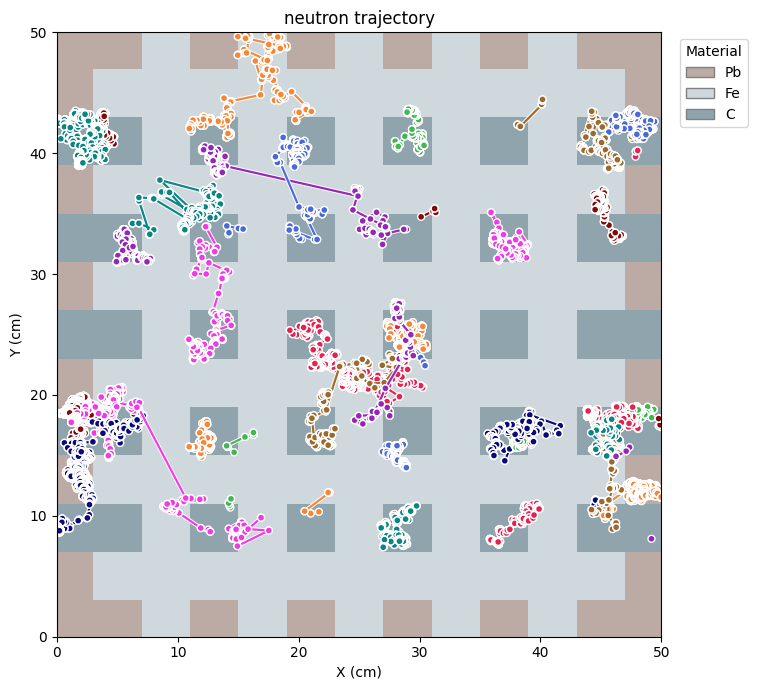

In [39]:
plotter = mcmr.ResultsPlotter("mcmr_results.xml")
plotter.plot_trajectories(world_xml="mcmr_world.xml")